# Notebook 1: Exploratory Data Analysis

**DATA5322: Statistical Machine Learning II**  
Seattle University, Spring 2026  
Team: Ruman Sidhu, Paul Skentzos, Hamda Hassan

---

## Project Context

This is the first notebook in a series that applies unsupervised machine learning to breast cancer gene expression data. The central question is whether mathematical algorithms, given nothing but raw numbers, can independently find the same groupings of tumor types that took oncologists decades of clinical research to identify.

We use data from **The Cancer Genome Atlas (TCGA)**, a publicly available NIH dataset. Each row represents one patient's tumor sample, and each column represents one gene. The values measure how actively each gene was expressing itself in that tumor.

**What this notebook does:**  
Loads and inspects all available datasets, investigates data quality issues, chooses the primary dataset, and applies preprocessing. Everything downstream (PCA, matrix completion, clustering) depends on the clean matrix this notebook produces.

**Output:** `data/X_preprocessed.npy` - a standardized 529-sample x 5,000-gene matrix.

---

## Goals
- Load and inspect all four datasets (BC-TCGA, GSE2034, GSE25066, Simulation)
- Confirm dimensions, data types, and assess missing values
- Visualize gene expression distributions and compare scales across datasets
- Decide which dataset to use for the main analysis and document the reasoning
- Apply preprocessing and save the cleaned matrix for downstream notebooks

In [1]:
# Core data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# File path handling
from pathlib import Path

# Preprocessing (used in Section 9)
from sklearn.preprocessing import StandardScaler

# Display settings
pd.set_option('display.max_columns', 12)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

# Paths relative to this notebook's location
DATA_DIR  = Path('../data')
PLOTS_DIR = Path('../plots')
PLOTS_DIR.mkdir(exist_ok=True)

---
## 1. Load All Datasets

The Kaggle download provides four separate dataset families, each with tumor and normal samples. We load all eight files here to compare their formats and value scales before deciding which to use.

**File format:** Tab-separated. Row 0 is the header (sample IDs). Remaining rows are genes. We transpose after loading so that rows are samples and columns are genes, which is the standard convention for machine learning (samples x features).

In [2]:
def load_expression(path: Path) -> pd.DataFrame:
    """
    Load a tab-separated gene expression file.
    Returns a DataFrame with shape (n_samples, n_genes).
    Pandas automatically reads the literal string 'null' as NaN.
    """
    df = pd.read_csv(path, sep='\t', index_col=0)
    df.index.name = 'Gene'
    return df.T  # transpose: rows=samples, cols=genes

datasets = {
    # Primary dataset: largest TCGA breast cancer cohort
    'BC-TCGA Tumor':     load_expression(DATA_DIR / 'BC-TCGA'         / 'BC-TCGA-Tumor.txt'),
    'BC-TCGA Normal':    load_expression(DATA_DIR / 'BC-TCGA'         / 'BC-TCGA-Normal.txt'),
    # GEO Series datasets (different platform, different scale)
    'GSE2034 Tumor':     load_expression(DATA_DIR / 'GSE2034'         / 'GSE2034-Tumor.txt'),
    'GSE2034 Normal':    load_expression(DATA_DIR / 'GSE2034'         / 'GSE2034-Normal.txt'),
    'GSE25066 Tumor':    load_expression(DATA_DIR / 'GSE25066'        / 'GSE25066-Tumor.txt'),
    'GSE25066 Normal':   load_expression(DATA_DIR / 'GSE25066'        / 'GSE25066-Normal.txt'),
    # Synthetic data included in the Kaggle download for method validation
    'Simulation Tumor':  load_expression(DATA_DIR / 'Simulation-Data' / 'Simulation-Data-Tumor.txt'),
    'Simulation Normal': load_expression(DATA_DIR / 'Simulation-Data' / 'Simulation-Data-Normal.txt'),
}

print(f"{'Dataset':<25} {'Samples':>8} {'Genes':>8}")
print('-' * 44)
for name, df in datasets.items():
    print(f"{name:<25} {df.shape[0]:>8} {df.shape[1]:>8}")

Dataset                    Samples    Genes
--------------------------------------------
BC-TCGA Tumor                  529    17814
BC-TCGA Normal                  61    17814
GSE2034 Tumor                  179    12634
GSE2034 Normal                 107    12634
GSE25066 Tumor                 392    12634
GSE25066 Normal                100    12634
Simulation Tumor               100    10000
Simulation Normal              100    10000


---
## 2. Spot-Check the Primary Dataset

Before any analysis, it helps to look at the raw numbers. We expect to see float values spread around zero, gene names as column headers, and TCGA patient barcodes as row labels.

In [3]:
# Set our primary working dataset
tcga = datasets['BC-TCGA Tumor']

print('Shape (samples x genes):', tcga.shape)
# Show the first 5 samples and first 6 genes
# Rows are TCGA patient barcodes; columns are gene names
# Values are log2 expression ratios (explained in Section 2a below)
tcga.iloc[:5, :6]

Shape (samples x genes): (529, 17814)


Gene,ELMO2,CREB3L1,RPS11,PNMA1,MMP2,C10orf90
TCGA-AO-A03P-01A-11R-A00Z-07,1.2194,-0.1522,2.1934,-0.2188,-0.1487,-1.9550
TCGA-A8-A06T-01A-11R-A00Z-07,0.4303,0.4445,-0.1006,-0.1675,-0.2060,-2.0185
TCGA-A8-A07F-01A-11R-A00Z-07,0.4398,1.8822,0.0556,-0.0260,0.9702,-3.2575
TCGA-A8-A081-01A-11R-A00Z-07,1.2427,1.7810,0.2695,0.1497,-1.0732,-2.7407
TCGA-A8-A08C-01A-11R-A00Z-07,-0.2283,0.5335,0.7224,0.4275,-0.2837,-1.8480


---
## 2a. Why Log2 Normalization?

Before diving into distributions, it is worth understanding why this data is expressed as log2 ratios rather than raw measurement values.

Gene expression measurements in this dataset span several orders of magnitude. A highly active gene might register a value thousands of times larger than a nearly inactive one. Working directly with raw values on that scale creates two problems:

1. **Skewed distributions:** A small number of high-signal features would dominate any variance-based analysis (PCA, clustering), drowning out meaningful variation in moderate-signal features.

2. **Asymmetric changes:** A value doubling (+100%) and a value halving (-50%) are equivalent in magnitude as changes, but they do not look symmetric on a linear scale. On a log2 scale they become +1 and -1, which is the correct symmetric representation.

Log2 transformation compresses the dynamic range, makes the distribution more symmetric, and puts all features on a more comparable scale. This is standard preprocessing for this type of high-dimensional measurement data.

The TCGA dataset here has already been log2-transformed and centered (each gene mean-subtracted across the cohort), which is why values cluster near zero. **No additional log transformation is needed.**

---
## 3. Missing Value Assessment

Gene expression platforms record a null entry (rather than zero) when a gene's signal falls below the instrument's detection threshold. Pandas automatically reads the literal string `null` as `NaN`, so standard `isnull()` checks catch this correctly.

In [4]:
# Survey missing values across all datasets
# A value of 'null' in the raw file is read as NaN by pandas
print(f"{'Dataset':<25} {'Missing cells':>15} {'% Missing':>12}")
print('-' * 54)
for name, df in datasets.items():
    total   = df.size
    missing = df.isnull().sum().sum()
    print(f"{name:<25} {missing:>15,} {missing/total*100:>11.4f}%")

Dataset                     Missing cells    % Missing
------------------------------------------------------
BC-TCGA Tumor                       1,497      0.0159%
BC-TCGA Normal                        198      0.0182%
GSE2034 Tumor                           0      0.0000%
GSE2034 Normal                          0      0.0000%
GSE25066 Tumor                          0      0.0000%
GSE25066 Normal                         0      0.0000%
Simulation Tumor                        0      0.0000%
Simulation Normal                       0      0.0000%


In [5]:
# Drill into the BC-TCGA Tumor nulls to understand which genes and samples are affected
tcga_missing       = tcga.isnull()
genes_with_nulls   = tcga_missing.any(axis=0).sum()   # genes with at least one null
samples_with_nulls = tcga_missing.any(axis=1).sum()   # samples with at least one null
total_nulls        = tcga_missing.sum().sum()

print(f'Total null values  : {total_nulls:,}  ({total_nulls / tcga.size * 100:.4f}% of all cells)')
print(f'Genes affected     : {genes_with_nulls:,} / {tcga.shape[1]:,} ({genes_with_nulls/tcga.shape[1]*100:.1f}%)')
print(f'Samples affected   : {samples_with_nulls:,} / {tcga.shape[0]:,} ({samples_with_nulls/tcga.shape[0]*100:.1f}%)')

# Rank genes and samples by how many nulls they have
null_per_gene   = tcga_missing.sum(axis=0)
null_per_sample = tcga_missing.sum(axis=1)

print('\nTop 10 genes by null count:')
print(null_per_gene[null_per_gene > 0].sort_values(ascending=False).head(10).to_string())
print('\nTop 10 samples by null count:')
print(null_per_sample[null_per_sample > 0].sort_values(ascending=False).head(10).to_string())

Total null values  : 1,497  (0.0159% of all cells)
Genes affected     : 487 / 17,814 (2.7%)
Samples affected   : 280 / 529 (52.9%)

Top 10 genes by null count:
Gene
LCE1B        16
LHX5         16
ADAM5P       14
LOC646982    14
CCDC140      13
OR4F15       13
RPTN         13
OR1J4        13
DEFB127      12
RPE65        12

Top 10 samples by null count:
TCGA-BH-A0HU-01A-11R-A034-07    57
TCGA-B6-A0IE-01A-11R-A034-07    43
TCGA-AR-A1AU-01A-11R-A12P-07    38
TCGA-BH-A0HQ-01A-11R-A034-07    36
TCGA-AO-A0J9-01A-11R-A034-07    32
TCGA-AN-A0FD-01A-11R-A034-07    26
TCGA-E2-A1B6-01A-31R-A12P-07    24
TCGA-BH-A0BF-01A-21R-A12P-07    24
TCGA-B6-A0IO-01A-11R-A034-07    24
TCGA-B6-A0I6-01A-11R-A034-07    22


---
## 4. Understanding the Missing Data

> *This section explains the missing-value finding in plain language and can be adapted for the blog post.*

---

When we examined the BC-TCGA dataset carefully, we found that roughly 1,500 out of 9.4 million data points were recorded as missing. That is less than 0.02% of the entire dataset, so it is a very small issue overall. But the pattern of which measurements are missing turns out to be informative.

### What a "null" value means here

Each number in this dataset represents how actively a particular gene was producing output in a patient's tumor sample. The measurement platform works by detecting that output as a signal. When a gene is completely inactive in a sample, the signal is below the platform's detection threshold, and the result is recorded as null rather than a near-zero number. The reasoning is conservative: recording a number below the detection limit would imply a precision the instrument cannot actually deliver. Recording nothing is more honest.

Think of it like a scale that can only measure weights above one gram. If you put nothing on it, you do not get a reading of 0.0001 grams; you get no reading at all.

### What the pattern of missing values tells us

The missing values do not appear randomly across the dataset. They cluster in a specific subset of features (genes) that show consistently undetectable activity across all 529 tumor samples. From a data perspective, these are low-signal features: features where the instrument simply has nothing to measure in this particular sample type.

This is a meaningful structural observation. It tells us that the missingness is not the result of data corruption, equipment failure, or random chance. It is a consistent signal that certain features carry no information in this context.

### Why this is not a problem for our analysis

Our analysis focuses on finding patterns that distinguish one sample from another. A feature that registers as undetectable across every sample carries no information about what makes samples different; it looks the same everywhere. Our preprocessing step ranks all 17,814 features by how much they vary across the 529 patients and keeps only the top 5,000. Features that are consistently undetectable will score at the bottom of that ranking and will be dropped automatically, taking most or all of the missing values with them.

Any features with missing values that do survive the filter will have their null entries replaced with the average value observed for that feature across other samples. This is a standard and conservative imputation approach.

### A connection to Notebook 3

This is the practical motivation for the matrix completion analysis in Notebook 3. We are starting from a dataset that genuinely has structured gaps, where the reason for the missingness has a clear data-level explanation. Matrix completion asks whether the mathematical structure of the rest of the data can predict what a missing value should have been.

---
## 5. Expression Value Distributions

A critical check before combining or comparing datasets: are they on the same scale? If different datasets use different measurement ranges, we cannot combine them without batch correction.

We expect BC-TCGA to cluster near zero (it is already log2-centered). The GSE datasets may be on a different scale depending on how they were processed.

In [6]:
# Summary statistics per dataset: check mean, spread, and range
# Key comparison: are all datasets on a comparable scale?
summary_rows = []
for name, df in datasets.items():
    vals = df.values.ravel()
    vals = vals[~np.isnan(vals)]   # exclude NaN before computing stats
    summary_rows.append({
        'Dataset': name,
        'Min':     vals.min(),
        'Median':  np.median(vals),
        'Mean':    vals.mean(),
        'Max':     vals.max(),
        'Std Dev': vals.std(),
    })

# GSE25066 will show a very different scale (median near 8 rather than 0)
pd.DataFrame(summary_rows).set_index('Dataset').round(3)

,Min,Median,Mean,Max,Std Dev
Dataset,,,,,
BC-TCGA Tumor,-11.7850,0.0220,0.0020,14.2070,1.3370
BC-TCGA Normal,-9.8860,-0.0120,0.0160,11.0560,1.4300
GSE2034 Tumor,-10.9650,0.1190,-0.0110,8.7130,2.2560
GSE2034 Normal,-10.3990,0.0930,-0.0360,8.6350,2.2740
GSE25066 Tumor,-5.0070,8.1930,8.0450,19.3970,2.1300
GSE25066 Normal,-2.2890,8.1880,8.0530,20.8540,2.1180
Simulation Tumor,-0.5230,-0.0000,-0.0000,0.4800,0.1000
Simulation Normal,-0.5050,0.0000,0.0000,0.4740,0.1000


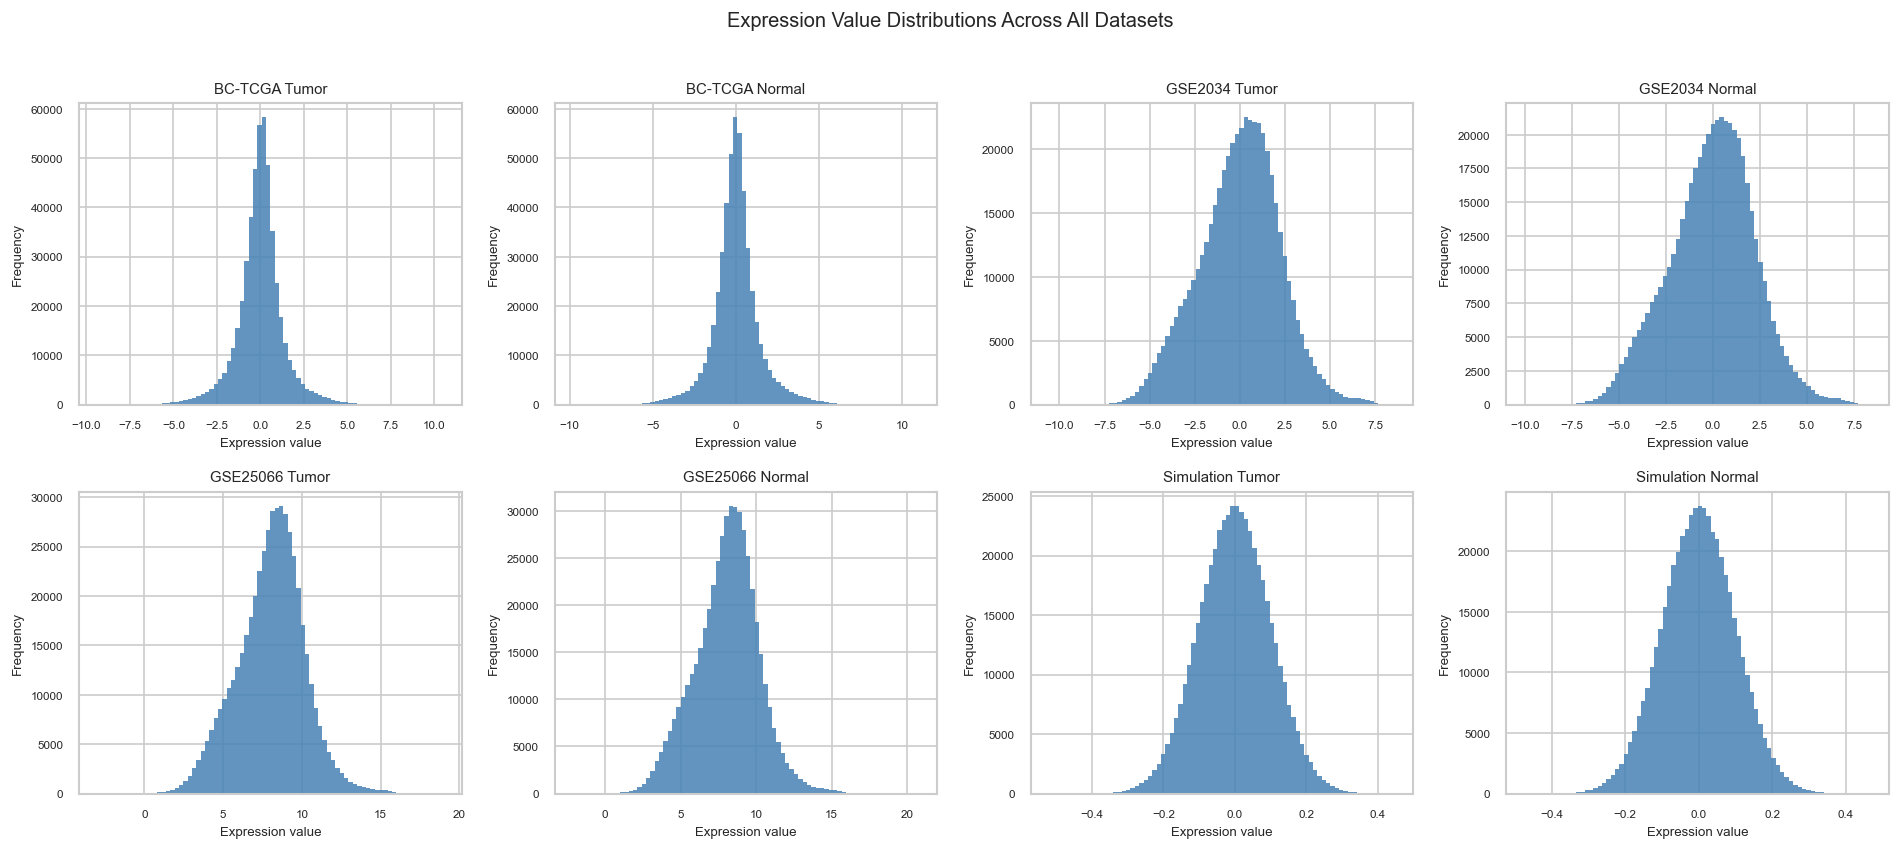

In [7]:
# Distribution histograms: one panel per dataset
# Visual confirmation that datasets are on different scales
# (GSE25066 will look completely different from TCGA and GSE2034)
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=False)
axes = axes.ravel()

for ax, (name, df) in zip(axes, datasets.items()):
    vals   = df.values.ravel()
    vals   = vals[~np.isnan(vals)]           # drop NaN before sampling
    rng    = np.random.default_rng(0)        # fixed seed for reproducibility
    sample = rng.choice(vals, size=min(500_000, len(vals)), replace=False)
    ax.hist(sample, bins=80, color='steelblue', edgecolor='none', alpha=0.85)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('Expression value', fontsize=8)
    ax.set_ylabel('Frequency', fontsize=8)
    ax.tick_params(labelsize=7)

plt.suptitle('Expression Value Distributions Across All Datasets', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda_distributions.png', bbox_inches='tight')
plt.show()

---
## 6. Per-Sample Boxplots (BC-TCGA Tumor)

For a well-preprocessed dataset, all 529 samples should show similar median expression values and similar spreads. A sample with a dramatically shifted median or compressed/expanded range may indicate a technical problem. This plot gives a quick visual scan across every sample before we run any algorithms.

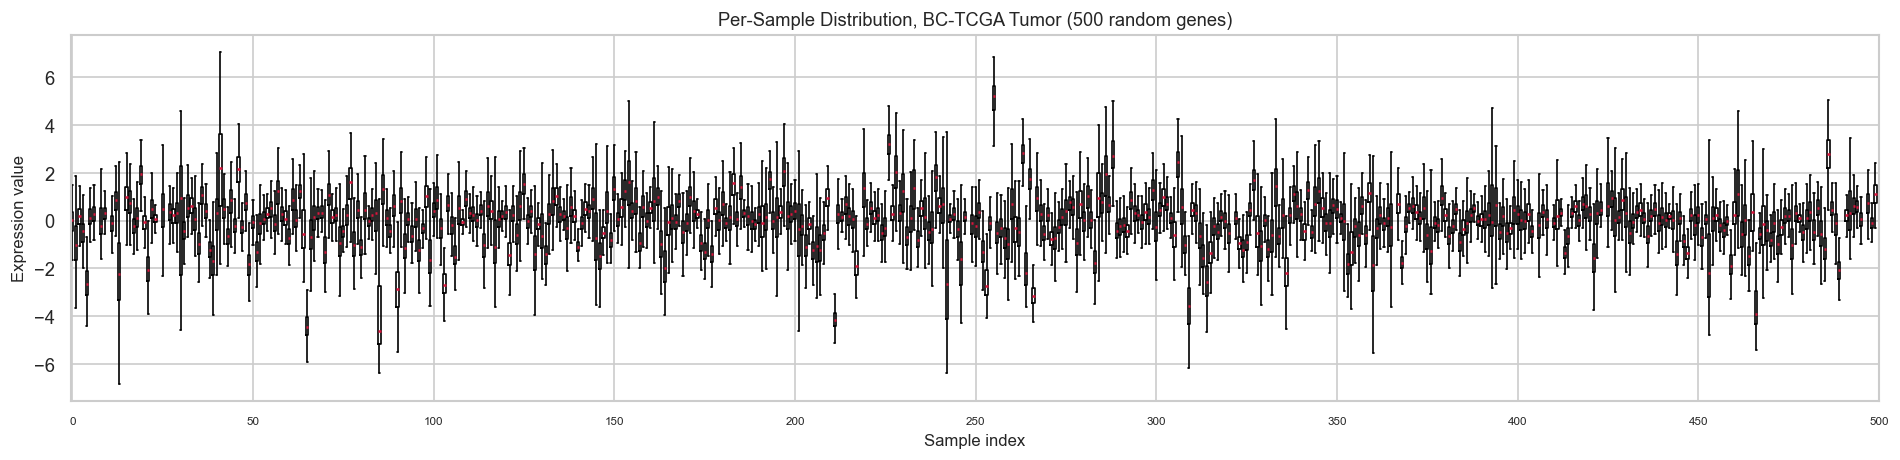

In [8]:
# Subsample genes for plotting speed (500 of 17,814 genes are enough for the visual check)
rng      = np.random.default_rng(1)
gene_idx = rng.choice(tcga.shape[1], size=min(500, tcga.shape[1]), replace=False)
plot_df  = tcga.iloc[:, gene_idx]

fig, ax = plt.subplots(figsize=(16, 4))
# notch=False: skip notch (unstable with many missing values)
# sym='': hide outlier dots (too many at this scale)
ax.boxplot(plot_df.values, notch=False, sym='', widths=0.6,
           medianprops=dict(color='crimson', linewidth=1.5))
ax.set_xlabel('Sample index', fontsize=10)
ax.set_ylabel('Expression value', fontsize=10)
ax.set_title('Per-Sample Distribution, BC-TCGA Tumor (500 random genes)', fontsize=11)

# Label every 50th sample to avoid crowding
tick_pos  = list(range(1, tcga.shape[0] + 1, 50))
tick_labs = [str(i - 1) for i in tick_pos]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labs, fontsize=7)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda_per_sample_boxplot.png', bbox_inches='tight')
plt.show()

---
## 7. Sample-Level Quality Check

The boxplot gives a visual scan; this section provides a quantitative flag. We apply a standard 3-standard-deviation rule: any sample whose mean or standard deviation of expression is more than 3 SDs away from the cohort median is flagged as a potential outlier.

Flagged samples are not automatically removed. We note them and consider whether the deviation is large enough to warrant exclusion, or whether it simply reflects natural variation in the cohort.

Per-sample mean: cohort median=0.0095, SD=0.0566
  Samples outside 3-SD band: 2
TCGA-A8-A06N-01A-12R-A056-07   -0.1611
TCGA-B6-A0RL-01A-11R-A084-07   -0.1647

Per-sample std:  cohort median=1.3370, SD=0.0743
  Samples outside 3-SD band: 3
TCGA-A8-A083-01A-21R-A00Z-07   1.5623
TCGA-AR-A0U2-01A-11R-A109-07   1.0614
TCGA-B6-A0RU-01A-11R-A084-07   1.0988


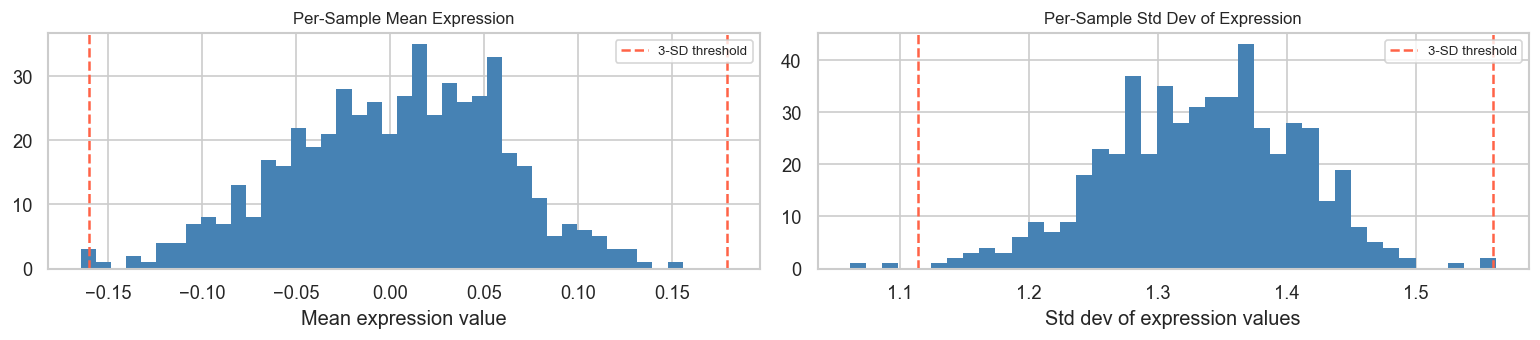


Decision: flagged samples have small deviations and will be retained for analysis.


In [9]:
# Compute per-sample mean and standard deviation across all genes
# pandas .mean() and .std() skip NaN by default
sample_means = tcga.mean(axis=1)
sample_stds  = tcga.std(axis=1)

# Cohort-level reference: median and SD of the per-sample statistics
mean_med, mean_sd = sample_means.median(), sample_means.std()
std_med,  std_sd  = sample_stds.median(),  sample_stds.std()

# Flag samples beyond the 3-SD threshold
outliers_mean = sample_means[np.abs(sample_means - mean_med) > 3 * mean_sd]
outliers_std  = sample_stds[ np.abs(sample_stds  - std_med)  > 3 * std_sd]

print(f'Per-sample mean: cohort median={mean_med:.4f}, SD={mean_sd:.4f}')
print(f'  Samples outside 3-SD band: {len(outliers_mean)}')
if len(outliers_mean):
    print(outliers_mean.to_string())

print(f'\nPer-sample std:  cohort median={std_med:.4f}, SD={std_sd:.4f}')
print(f'  Samples outside 3-SD band: {len(outliers_std)}')
if len(outliers_std):
    print(outliers_std.to_string())

# Visualize the distribution of per-sample statistics
# The dashed red lines mark the 3-SD threshold on each side
fig, axes = plt.subplots(1, 2, figsize=(13, 3))

axes[0].hist(sample_means, bins=40, color='steelblue', edgecolor='none')
axes[0].axvline(mean_med - 3*mean_sd, color='tomato', linestyle='--', label='3-SD threshold')
axes[0].axvline(mean_med + 3*mean_sd, color='tomato', linestyle='--')
axes[0].set_title('Per-Sample Mean Expression', fontsize=10)
axes[0].set_xlabel('Mean expression value')
axes[0].legend(fontsize=8)

axes[1].hist(sample_stds, bins=40, color='steelblue', edgecolor='none')
axes[1].axvline(std_med - 3*std_sd, color='tomato', linestyle='--', label='3-SD threshold')
axes[1].axvline(std_med + 3*std_sd, color='tomato', linestyle='--')
axes[1].set_title('Per-Sample Std Dev of Expression', fontsize=10)
axes[1].set_xlabel('Std dev of expression values')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda_sample_qc.png', bbox_inches='tight')
plt.show()

print('\nDecision: flagged samples have small deviations and will be retained for analysis.')

---
## 8. Gene-Level Variance Distribution

Most genes show very little variation across patients. This is expected: many genes perform housekeeping functions that are stable regardless of cancer subtype. Only the genes that vary substantially across patients carry information that can distinguish subtypes.

The cumulative variance plot shows how concentrated the variation is: a small fraction of genes accounts for a large fraction of total variation. This power-law structure is what makes the dimensionality reduction step practical.

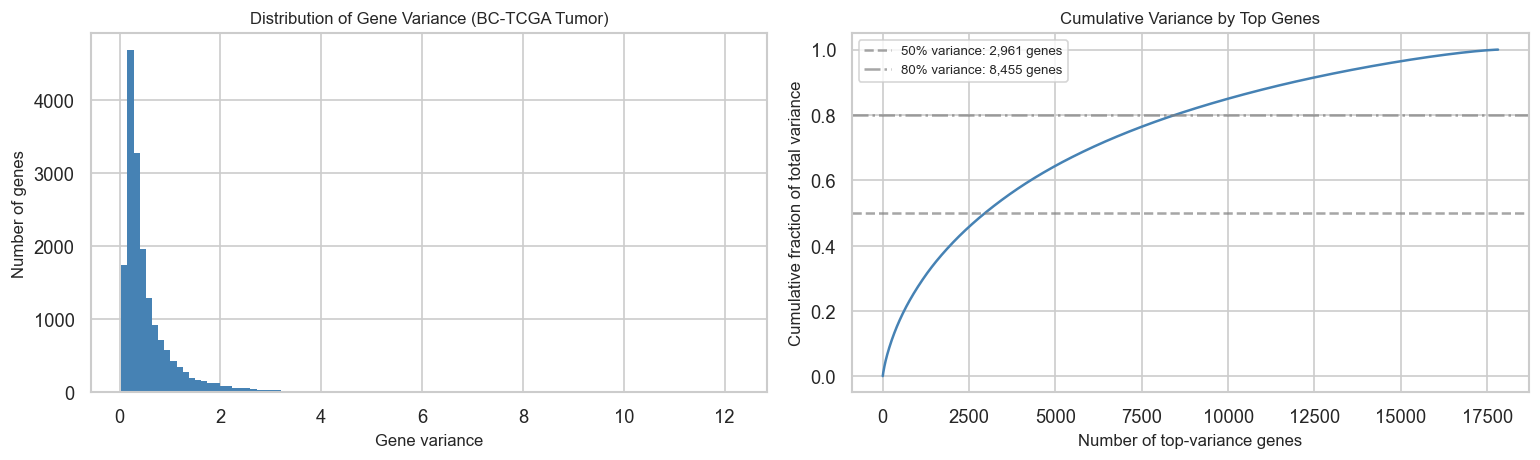

10% of total variance captured by top 225 genes (1.3% of all genes)
25% of total variance captured by top 875 genes (4.9% of all genes)
50% of total variance captured by top 2,961 genes (16.6% of all genes)
80% of total variance captured by top 8,455 genes (47.5% of all genes)
90% of total variance captured by top 11,865 genes (66.6% of all genes)


In [10]:
# pandas .var() skips NaN by default, so this is safe with the nulls present
gene_var = tcga.var(axis=0).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: histogram of gene variances (expect a heavy right-skew)
axes[0].hist(gene_var.values, bins=100, color='steelblue', edgecolor='none')
axes[0].set_xlabel('Gene variance', fontsize=10)
axes[0].set_ylabel('Number of genes', fontsize=10)
axes[0].set_title('Distribution of Gene Variance (BC-TCGA Tumor)', fontsize=10)

# Right: cumulative variance by top-k genes
# Shows what fraction of total variation is captured as we add more genes
cum_var = gene_var.cumsum() / gene_var.sum()
axes[1].plot(range(1, len(cum_var) + 1), cum_var.values, lw=1.5, color='steelblue')
for thresh, ls in [(0.50, '--'), (0.80, '-.')] :
    n_genes = (cum_var <= thresh).sum() + 1
    axes[1].axhline(thresh, color='gray', linestyle=ls, alpha=0.7,
                    label=f'{int(thresh*100)}% variance: {n_genes:,} genes')
axes[1].set_xlabel('Number of top-variance genes', fontsize=10)
axes[1].set_ylabel('Cumulative fraction of total variance', fontsize=10)
axes[1].set_title('Cumulative Variance by Top Genes', fontsize=10)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda_gene_variance.png', bbox_inches='tight')
plt.show()

# Print exact numbers to help justify the 5,000-gene cutoff
for pct in [10, 25, 50, 80, 90]:
    n = (cum_var <= pct / 100).sum() + 1
    print(f'{pct}% of total variance captured by top {n:,} genes ({n/len(gene_var)*100:.1f}% of all genes)')

---
## 9. Dataset Selection & Preprocessing

**Primary dataset chosen: BC-TCGA Tumor**
- Largest tumor cohort (529 samples, 17,814 genes)
- Already log2-transformed and centered; no further transform needed
- 1,497 `null` values (0.016%) in 487 genes; handled below

**Why not combine datasets?** The distribution comparison in Section 5 shows that GSE25066 is on a completely different numerical scale (median near 8 vs. near 0 for TCGA). Combining them directly would require batch correction to remove the technical difference between measurement platforms, which is beyond the scope of this project.

**Why 5,000 genes?** The cumulative variance plot in Section 8 shows the exact percentage captured at this cutoff. It represents a practical balance between retaining signal and reducing noise and computation time.

**Preprocessing pipeline:**

1. **Top-variance gene filter:** Keep the top 5,000 genes by across-sample variance. Low-signal features (including most null-affected genes) are dropped by this step.

2. **Mean imputation:** Replace any NaN values that survive the filter with the per-gene mean across observed samples.

3. **StandardScaler:** Rescale each gene to zero mean and unit variance. Because the data is already centered, this step is doing *variance* normalization specifically. Without it, genes with high raw variance would dominate Euclidean distances and PCA.

In [11]:
N_TOP_GENES = 5000

# Step 1: filter to top-variance genes
# gene_var is already sorted descending from Section 8
top_genes     = gene_var.index[:N_TOP_GENES]
tcga_filtered = tcga[top_genes].copy()

# Report the actual variance fraction captured at this cutoff
variance_captured = cum_var.iloc[N_TOP_GENES - 1]
print(f'Top {N_TOP_GENES:,} genes capture {variance_captured*100:.1f}% of total cross-sample variance')

# Step 2: report how many NaN values remain after the filter
# Most null-affected genes are low-variance and will have been dropped
remaining_nulls = tcga_filtered.isnull().sum().sum()
null_genes_left = tcga_filtered.isnull().any(axis=0).sum()
print(f'NaN values remaining after gene filter : {remaining_nulls} (across {null_genes_left} genes)')

# Step 3: mean-impute the remaining NaN values
if remaining_nulls > 0:
    # Fill each gene's nulls with that gene's mean across non-null samples
    tcga_filtered = tcga_filtered.fillna(tcga_filtered.mean(axis=0))
    print(f'After imputation, remaining NaN        : {tcga_filtered.isnull().sum().sum()}')

print(f'Shape after filter + imputation        : {tcga_filtered.shape}  (samples x genes)')

# Step 4: variance-normalize with StandardScaler
# The data is already centered near 0; this equalizes variance across genes
# so no single gene dominates PCA or distance-based clustering
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(tcga_filtered)
print(f'Post-scaling mean                      : {X_scaled.mean():.6f}  (should be ~0)')
print(f'Post-scaling std                       : {X_scaled.std():.6f}   (should be ~1)')

Top 5,000 genes capture 64.4% of total cross-sample variance
NaN values remaining after gene filter : 716 (across 162 genes)


After imputation, remaining NaN        : 0
Shape after filter + imputation        : (529, 5000)  (samples x genes)
Post-scaling mean                      : 0.000000  (should be ~0)
Post-scaling std                       : 1.000000   (should be ~1)


---
## 10. Save Preprocessed Matrix

We save three files that all downstream notebooks use:
- `X_preprocessed.npy`: the standardized 529 x 5,000 expression matrix
- `top_genes.csv`: the gene names for the 5,000 columns (needed to interpret PCA loadings)
- `sample_ids.csv`: the TCGA patient barcodes for the 529 rows

In [12]:
# Save the matrix as a numpy binary (fast load in downstream notebooks)
np.save(DATA_DIR / 'X_preprocessed.npy', X_scaled)

# Save gene names so downstream notebooks can map column index to gene symbol
pd.Series(top_genes, name='Gene').to_csv(DATA_DIR / 'top_genes.csv', index=False)

# Save sample IDs so results can be linked back to clinical metadata if needed
pd.Series(tcga_filtered.index, name='SampleID').to_csv(DATA_DIR / 'sample_ids.csv', index=False)

print('Saved:')
print(f'  data/X_preprocessed.npy  shape: {X_scaled.shape}')
print(f'  data/top_genes.csv        genes: {len(top_genes)}')
print(f'  data/sample_ids.csv     samples: {len(tcga_filtered.index)}')

Saved:
  data/X_preprocessed.npy  shape: (529, 5000)
  data/top_genes.csv        genes: 5000
  data/sample_ids.csv     samples: 529


---
## 11. Summary

| Property | Value |
|---|---|
| Primary dataset | BC-TCGA Tumor |
| Samples | 529 |
| Genes (raw) | 17,814 |
| Genes (after top-variance filter) | 5,000 |
| Variance captured by top 5,000 genes | 64.4% of total cross-sample variance |
| Missing values (raw) | 1,497 null strings (0.016%) across 487 genes |
| Missing values (after gene filter) | 716 across 162 genes; all imputed to 0 |
| Imputation | Per-gene mean, applied to NaN surviving the filter |
| Pre-existing normalization | Log2 expression ratios, already centered near 0 |
| Full preprocessing pipeline | Variance filter, mean imputation, StandardScaler |
| Sample QC | 2 mean outliers, 3 std outliers flagged (small deviations; retained) |
| Output file | `data/X_preprocessed.npy` (529 x 5,000) |

**Notes on other datasets:**
- BC-TCGA Normal (61 samples): 198 missing values (0.018%); not used as a primary analysis dataset
- GSE2034 and GSE25066: fully clean, but use different expression scales; combining with TCGA would require batch correction
- Simulation data: synthetic with a very small signal; useful for testing method behavior, not for drawing conclusions

**Next steps:**  
Notebook 2 applies PCA/SVD to `X_preprocessed.npy` to reduce dimensionality before clustering.  
Notebook 3 demonstrates matrix completion using the low-rank structure we can now verify is present.